In [1]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

from dataset import NNUEIterableDataset

In [2]:
dataloader = DataLoader(
    NNUEIterableDataset("../data/gensfen", batch_size=1000),
    batch_size=None,
    num_workers=8,
    persistent_workers=True,
    prefetch_factor=4,
)

In [3]:
buckets = np.linspace(-10000, 10000, 100)
counts = np.zeros(100)
wins = np.zeros(100)

for batch in dataloader:
    b, w, s, r, t = batch

    s = np.clip(s, -10000, 10000)

    # digitize returns the indices of the buckets [1, ..., len(buckets)]
    bin_indices = np.digitize(s, buckets) - 1  # Shift to zero-indexed

    # keep only scores that fell within the buckets
    mask = (bin_indices >= 0) & (bin_indices < len(buckets))
    bin_indices = bin_indices[mask]
    r_valid = r[mask]

    # Update counts and wins per bucket
    for idx, result in zip(bin_indices, r_valid):
        counts[idx] += 1
        wins[idx] += result

perf = wins / counts

In [6]:
buckets = buckets / (127*64)

In [11]:
targets = torch.sigmoid(torch.tensor(buckets*4)).numpy()

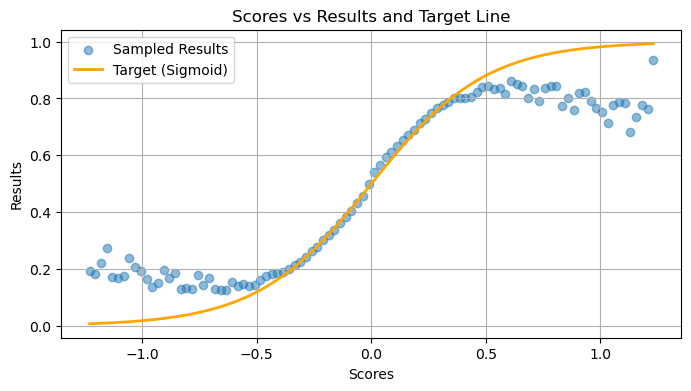

In [12]:
plt.figure(figsize=(8, 4))
plt.scatter(buckets, perf, alpha=0.5, label='Sampled Results')
plt.plot(buckets, targets, color='orange', label='Target (Sigmoid)', linewidth=2)

plt.xlabel('Scores')
plt.ylabel('Results')
plt.title('Scores vs Results and Target Line')
# plt.xlim(-10000, 10000)
plt.grid(True)
plt.legend()
plt.show()